In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

# Get data from arrayExpress: SG treatment subcut

UMAP not yet available on arrayExpress. Implement once this has been updated...

In [7]:
# # Download data from arrayExpress and reassemble anndata object 
# from utils_arrayExpress import get_public_study_adata

# accession = "E-MTAB-16433"
# download_dir = '../data_arrayExpress'
# adata = get_public_study_adata(
#     accession=accession,
#     download_dir=download_dir,

# )
# adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16433 in: ../data_arrayExpress/E-MTAB-16433
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16433
      Inferred 1 dataset representation: SG (full prefix: treatment_HD4246_SG)
      Selected dataset for in-memory loading: SG (full prefix: treatment_HD4246_SG)
[3/3] Preparing selected dataset.
      No saved h5ad found for selected dataset; assembling from source files.
      Loaded dataset shape: (7330, 25470)
      Saved selected dataset to: E-MTAB-16433/E-MTAB-16433_SG.h5ad


AnnData object with n_obs × n_vars = 7330 × 25470
    obs: 'sample_id', 'library_id', 'treatment', 'mouse_ID', 'batch', 'leiden'
    uns: 'dataset_prefix', 'source_files', 'saved_h5ad'
    layers: 'counts', 'log1p'

# Read data from disk: SG treatment subcut

In [9]:
# Read input data
dir_data = '../data/'
file = os.path.join(dir_data, "treatment_HD4246_SG.h5ad")
adata = sc.read_h5ad(file)

## Annotation

In [10]:
# Add annotation
from utils_treatment_HD4246_SG import anno_leiden_dict

if adata.uns['leiden']['params']['resolution'] == anno_leiden_dict['resolution']:
    adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
else:
    raise ValueError("Resolution mismatch between adata.uns['leiden'] and anno_leiden_dict.")

In [11]:
# # Ensure order of leiden clustering (str) is available
# adata.obs['leiden'] = adata.obs['leiden'].astype(str)
# sc.pl.umap(adata, color='leiden', legend_loc='on data', show=True, frameon=False)

In [12]:
# # Add annotation to dataset
# from utils_treatment_HD4246_SG import anno_leiden_dict

# adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
# # Order annotation levels by leiden cluster number
# adata.obs['anno'] = pd.Categorical(
#     adata.obs['anno'],
#     categories=[anno_leiden_dict['labels'][f'{i}'] for i in range(len(anno_leiden_dict['labels']))],
#     ordered=True
# )

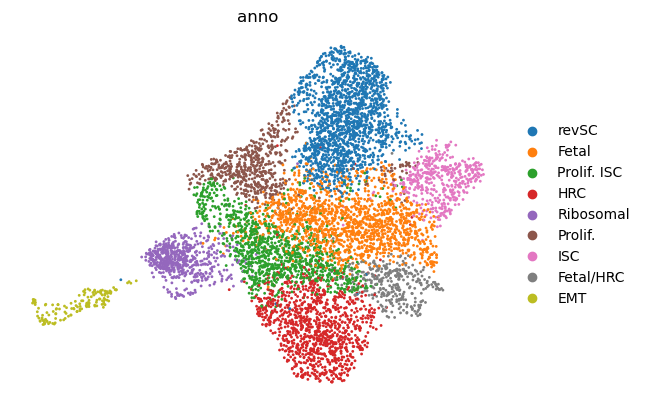

In [13]:
# Annotation UMAP
sc.pl.umap(adata, color=['anno'], frameon=False, title=None)

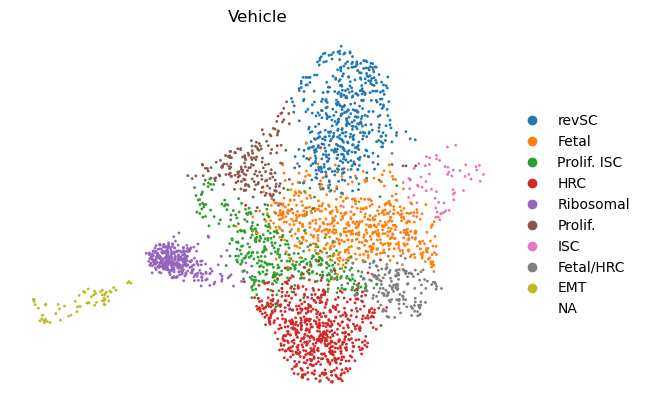

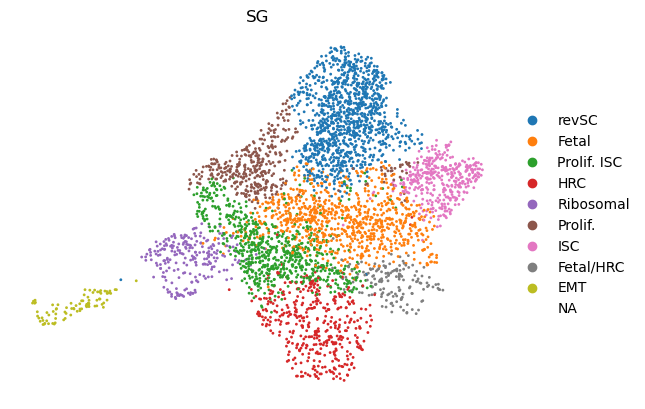

In [14]:
###  UMAP split by treatment condition

# Observation masks
mask_vehicle = adata.obs['treatment'] == 'vehicle'
mask_SG = adata.obs['treatment'] == 'trodelvy'

# Plot UMAPs
sc.pl.umap(adata.copy(), color=['anno'], frameon=False, title='Vehicle', 
           mask_obs=mask_vehicle, na_color='white')

sc.pl.umap(adata.copy(), color=['anno'], frameon=False, title='SG', 
           mask_obs=mask_SG, na_color='white')

## Gene expression UMAP

UMAPs of gene expression patterns:


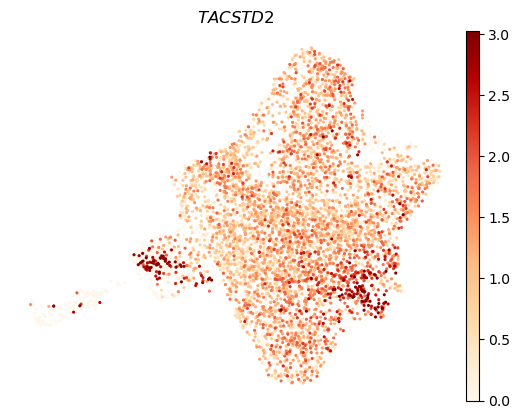

<Figure size 640x480 with 0 Axes>

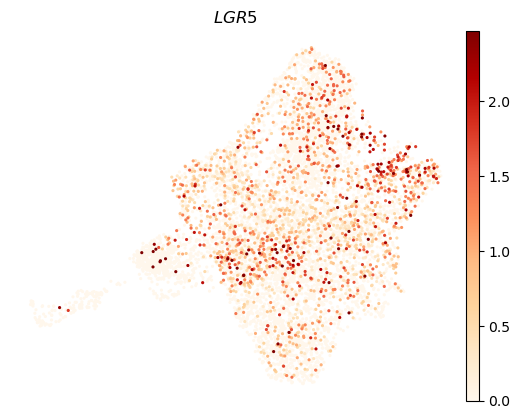

<Figure size 640x480 with 0 Axes>

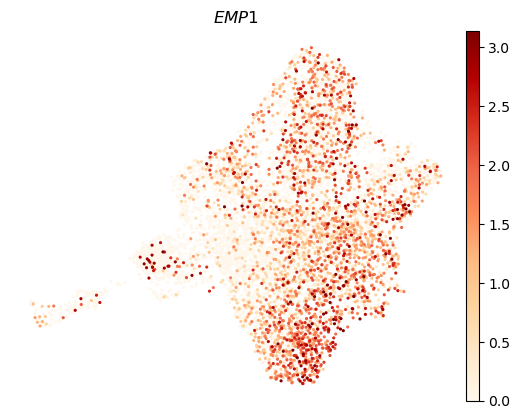

<Figure size 640x480 with 0 Axes>

In [15]:
# Features to plot
features = ['TACSTD2', 'LGR5', 'EMP1']

# Define plotting parameters
vmax = 'p99.5'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot and save UMAPs
    sc.pl.umap(
        adata, 
        color=feature, 
        size=dot_size, 
        cmap='OrRd', 
        vmax=vmax, 
        title=f"$\\it{{{feature}}}$",
        frameon=False
    )
    plt.tight_layout()
    plt.show()

## Treatment response

In [19]:
import pandas as pd
import numpy as np

cell_groups = 'anno'

# Relevant data
df = adata.obs[['sample_id', 'treatment', cell_groups]].copy()

# Count cells per sample–treatment–cluster
counts = (
    df.groupby(['sample_id', 'treatment', cell_groups])
      .size()
      .reset_index(name='count')
)

# Convert to frequencies within each sample+treatment
counts['freq'] = (
    counts.groupby(['sample_id', 'treatment'])['count']
          .transform(lambda x: x / x.sum())
)

# Pivot so each sample has freq per treatment; keep NaN where data is truly missing
freq_pivot = counts.pivot_table(
    index=['sample_id', cell_groups],
    columns='treatment',
    values='freq',
    aggfunc='mean',
    dropna=False  # keeps NaNs instead of filling with 0
)

# Replace structural zeros (= treatment not present for that sample) with NaN
# True zeros (cluster frequency = 0 within a sample) remain 0
freq_pivot = freq_pivot.replace(0, np.nan) # can do as no zero beyond structural zeros

# Compute cluster-wise mean and std across samples, per treatment
summary = (
    freq_pivot
    .groupby(cell_groups)
    .agg(['mean', 'std', 'count'])       # mean freq, SD, number of samples contributing
)

# Extract means per treatment
mean_trodelvy = summary['trodelvy']['mean']
mean_vehicle  = summary['vehicle']['mean']

# Compute log2 fold change based on MEANS
pseudocount = 0 # not needed
log2fc = np.log2((mean_trodelvy + pseudocount) / (mean_vehicle + pseudocount))
fc = (mean_trodelvy + pseudocount) / (mean_vehicle + pseudocount)

# Extract difference in percent
diff_percent = (mean_trodelvy - mean_vehicle)


# Final output
result = pd.DataFrame({
    'mean_vehicle': mean_vehicle,
    'mean_trodelvy': mean_trodelvy,
    'std_vehicle': summary['vehicle']['std'],
    'std_trodelvy': summary['trodelvy']['std'],
    # 'n_vehicle': summary['vehicle']['count'],
    # 'n_trodelvy': summary['trodelvy']['count'],
    'log2FC_trodelvy_vs_vehicle': log2fc,
    'FC_trodelvy_vs_vehicle': fc,
    'diff_trodelvy_vs_vehicle': diff_percent,
})
result.to_csv(f"../data_suppl/{accession}_Fig_03k.csv")
result.sort_values('log2FC_trodelvy_vs_vehicle', ascending=False).head(10)


/tmp/ipykernel_1518359/1974658962.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sample_id', 'treatment', cell_groups])
/tmp/ipykernel_1518359/1974658962.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts.groupby(['sample_id', 'treatment'])['count']
/tmp/ipykernel_1518359/1974658962.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq_pivot = counts.pivot_table(
/tmp/ipykernel_1518359/1974658962.py:38: FutureWarning

,mean_vehicle,mean_trodelvy,std_vehicle,std_trodelvy,log2FC_trodelvy_vs_vehicle,FC_trodelvy_vs_vehicle,diff_trodelvy_vs_vehicle
anno,,,,,,,
ISC,0.020563,0.091280,0.012841,0.013422,2.150269,4.439107,0.070717
revSC,0.174708,0.245467,0.054563,0.072940,0.490588,1.405018,0.070760
Prolif.,0.066812,0.090314,0.014301,0.031640,0.434838,1.351759,0.023502
Prolif. ISC,0.128030,0.171745,0.023543,0.045782,0.423788,1.341445,0.043715
EMT,0.018786,0.019383,0.016487,0.006128,0.045110,1.031761,0.000597
Fetal,0.206749,0.192906,0.034593,0.060730,-0.099980,0.933046,-0.013843
Fetal/HRC,0.057938,0.036397,0.017552,0.005307,-0.670683,0.628209,-0.021541
Ribosomal,0.110877,0.052686,0.042133,0.010842,-1.073472,0.475174,-0.058191
HRC,0.215537,0.099821,0.034979,0.027244,-1.110519,0.463127,-0.115716


In [20]:
# assemble dict which assigns 'up' if fold change > cutoff, 'down' if < 1/cutoff, else 'stable'
def get_treat_resp(x, cutoff):
    if x > (1 + cutoff):
        return 'up'
    elif x < (1 - cutoff):
        return 'down'
    else:
        return 'stable'
    
cutoff = 0.3
treat_resp_dict = {x: get_treat_resp(result.loc[x]['FC_trodelvy_vs_vehicle'], cutoff) for x in result.index}
treat_resp_dict

{'revSC': 'up',
 'Fetal': 'stable',
 'Prolif. ISC': 'up',
 'HRC': 'down',
 'Ribosomal': 'down',
 'Prolif.': 'up',
 'ISC': 'up',
 'Fetal/HRC': 'down',
 'EMT': 'stable'}

In [21]:
# Assign treatment response to adata.obs
adata.obs['treatment_resp'] = adata.obs['anno'].map(treat_resp_dict)

{'treatment_resp': {'order': ['down', 'up', 'stable'], 'colors': ['#5B84B1FF', '#FC766AFF', 'grey']}}


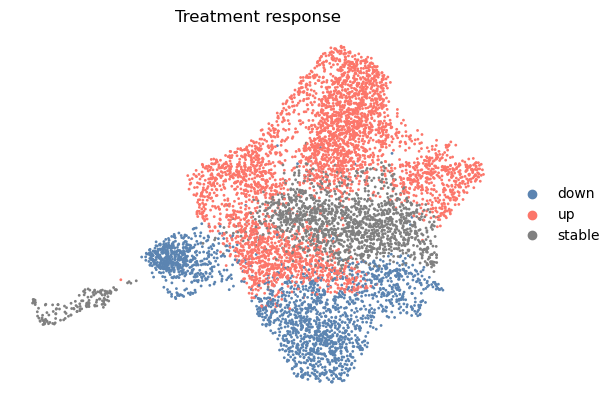

In [22]:
# Set color code and plot UMAP
from utils_treatment_HD4246_SG import color_code
print(color_code)

adata = set_color_code(adata, color_code, feature='treatment_resp')
sc.pl.umap(adata, color=['treatment_resp'], frameon=False, title="Treatment response")

/tmp/ipykernel_1518359/3213015425.py:25: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.violinplot(
/tmp/ipykernel_1518359/3213015425.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([feature_labels[f] for f in df['feature'].unique()])


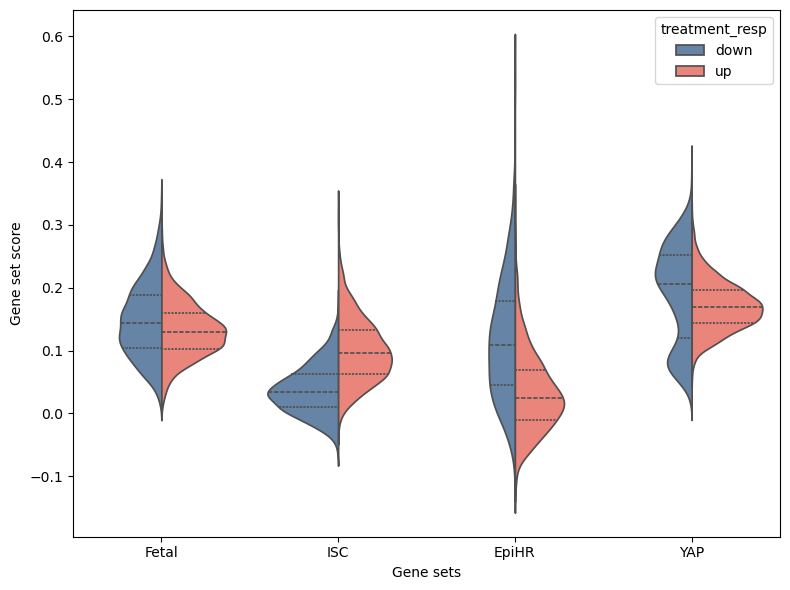

In [23]:
### Gene set expression across treatment response
features = ['score_fetal', 'score_Lgr5', 'score_epiHR', 'score_YAP']
feature_labels = {
    'score_fetal': 'Fetal',
    'score_Lgr5': 'ISC',
    'score_epiHR': 'EpiHR',
    'score_YAP': 'YAP'
}
split_by = 'treatment_resp'

# Extract data into DataFrame
df = adata.obs[[split_by]].copy()  # Copy the metadata into a DataFrame
for feature in features:        
    df[feature] = adata.obs_vector(feature, layer='normalized')
# To long format
df = df.melt(
    id_vars=[split_by], 
    value_vars=features, 
    var_name='feature', 
    value_name='value'
)

# Plot as violin plot
plt.figure(figsize=(8, 6))
ax = sns.violinplot(
    data=df, 
    x='feature', 
    y='value', 
    hue=split_by, 
    hue_order=['down', 'up'],
    split=True, 
    palette=color_code[split_by]['colors'],
    fill=True, 
    inner='quart'
)
plt.xlabel('Gene sets')
plt.ylabel('Gene set score')
# Replace x-tick labels
ax.set_xticklabels([feature_labels[f] for f in df['feature'].unique()])
plt.tight_layout()
plt.show()

In [24]:
df.to_csv(f"../data_suppl/{accession}_Fig_03l.csv", index=False)
df.head()

,treatment_resp,feature,value
0,up,score_fetal,0.146605
1,up,score_fetal,0.207185
2,stable,score_fetal,0.162056
3,up,score_fetal,0.191339
4,up,score_fetal,0.126882


In [25]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

rank_sum = []

# Test differential gene set score across treatment response
for score in gs_process:
    x = df[(df['feature'] == score) & (df['treatment_resp'] == 'up')]['value']
    y = df[(df['feature'] == score) & (df['treatment_resp'] == 'down')]['value']
    # Perform rank sum test
    rank_stat, rank_p_value = mannwhitneyu(x, y, alternative='two-sided', )
    
    # Append results to rank_sum
    rank_sum.append({
        "gene_set": score,
        "median_cl_dn": y.median(),
        "median_cl_up": x.median(),
        "mean_cl_dn": y.mean(),
        "mean_cl_up": x.mean(),
        "rank_statistic": rank_stat,
        "rank_p_value": rank_p_value,
    })

# Convert to DataFrame
rank_sum_df = pd.DataFrame(rank_sum)

# Apply multiple testing correction to the p-values
p_values = rank_sum_df["rank_p_value"].values
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')  # FDR correction (Benjamini-Hochberg)
# Add corrected p-values to the DataFrame
rank_sum_df["rank_p_value_FDR(BH)"] = corrected_p_values
rank_sum_df.to_csv(f"../data_suppl/{accession}_Fig_03l_test.csv", index=False)
rank_sum_df

,gene_set,median_cl_dn,median_cl_up,mean_cl_dn,mean_cl_up,rank_statistic,rank_p_value,rank_p_value_FDR(BH)
0,score_fetal,0.144284,0.130372,0.147672,0.132613,3187373.0,3.786977e-19,3.786977e-19
1,score_Lgr5,0.034425,0.095766,0.037833,0.100280,6236961.0,0.000000e+00,0.000000e+00
2,score_epiHR,0.108594,0.025337,0.116753,0.033257,1732366.0,7.701124e-244,1.540225e-243
3,score_YAP,0.205672,0.168828,0.190511,0.171265,2899272.0,3.582501e-43,4.776669e-43


# Get data from arrayExpress: SG treatment time course liver mets

Data format on arrayExpress needs double-checking...

In [26]:
# # Download data from arrayExpress and reassemble anndata object 
# from utils_arrayExpress import get_public_study_adata

# accession = "E-MTAB-16849"
# download_dir = '../data_arrayExpress'
# adata = get_public_study_adata(
#     accession=accession,
#     download_dir=download_dir,

# )
# adata